# MatForge — Notebook 01: Cook-Torrance Differentiable Renderer
#
# Standalone validation of the physically-based renderer used as a training signal
# in MatForge. This notebook must pass all tests before the renderer is integrated
# into the main training loop.
#
# The renderer implements the analytic Cook-Torrance BRDF in PyTorch with:
# - GGX/Trowbridge-Reitz NDF
# - Smith-Schlick geometry term (UE4 analytic-light variant)
# - Schlick Fresnel approximation
# - UE4 metallic workflow (baseColor + metallic + roughness)
#
# **All tests must be run in order.** Each cell produces a pass/fail result
# that determines whether the next cell is safe to execute.

## Cell 1 — Imports and environment check

In [1]:
import math
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
 
# Environment diagnostics — useful to capture for the project log
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32
print(f"\nRunning on: {DEVICE}")

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : Tesla T4
VRAM     : 15.6 GB

Running on: cuda


## Cell 2 — Core utility functions

In [2]:
def safe_normalize(x: torch.Tensor, dim: int = 1, eps: float = 1e-6) -> torch.Tensor:
    """
    L2-normalizes a tensor along `dim` with a minimum-norm clamp to prevent
    NaN gradients when the input norm approaches zero.
 
    Using eps=1e-6 rather than the default 1e-8 because float16 (AMP) has
    a minimum representable value of ~6e-8, making 1e-8 unreliable under autocast.
    """
    return x / torch.clamp(torch.linalg.norm(x, dim=dim, keepdim=True), min=eps)
 
 
def sample_light_directions(
    batch_size: int,
    num_lights: int,
    device: torch.device,
    dtype: torch.dtype,
    cos_theta_min: float = 0.25,
    cos_theta_max: float = 0.92,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Samples random light directions and white-ish radiance values for one training step.
 
    cos_theta is sampled uniformly in [cos_theta_min, cos_theta_max] to avoid:
    - Grazing lights (cos near 0): produce near-black renders with no gradient signal.
    - Head-on lights (cos near 1): produce saturated specular peaks that dominate the loss.
 
    Returns:
        dirs   : (B, K, 3) unit vectors in the upper hemisphere (z > 0).
        radiance: (B, K, 3) light colour/intensity, white with mild random jitter.
    """
    azimuth   = 2.0 * math.pi * torch.rand(batch_size, num_lights, device=device, dtype=dtype)
    cos_theta = cos_theta_min + (cos_theta_max - cos_theta_min) * torch.rand(
        batch_size, num_lights, device=device, dtype=dtype
    )
    sin_theta = torch.sqrt(torch.clamp(1.0 - cos_theta ** 2, min=1e-6))
 
    lx = torch.cos(azimuth) * sin_theta   # (B, K)
    ly = torch.sin(azimuth) * sin_theta
    lz = cos_theta
 
    dirs     = safe_normalize(torch.stack([lx, ly, lz], dim=-1), dim=-1)  # (B, K, 3)
    radiance = 0.9 + 0.2 * torch.rand(batch_size, num_lights, 1, device=device, dtype=dtype)
    radiance = radiance.expand(-1, -1, 3)
 
    return dirs, radiance
 
 
print("Utility functions defined.")

Utility functions defined.


## Cell 3 — BRDF component functions (individually testable)

In [3]:
def ggx_ndf(
    NoH: torch.Tensor,
    alpha2: torch.Tensor,
    eps: float = 1e-6,
) -> torch.Tensor:
    """
    GGX/Trowbridge-Reitz Normal Distribution Function.
 
    D(h) = alpha^2 / (pi * ((NoH^2 * (alpha^2 - 1) + 1)^2))
 
    alpha = roughness^2 following the UE4 convention (perceptual roughness remapping).
    The denominator is clamped to prevent division by zero when roughness -> 0 and NoH -> 1,
    which would cause an infinitely narrow specular lobe and exploding gradients.
    """
    denom = (NoH * NoH) * (alpha2 - 1.0) + 1.0
    return alpha2 / torch.clamp(math.pi * denom * denom, min=eps)
 
 
def smith_schlick_g1(
    NdotX: torch.Tensor,
    k: torch.Tensor,
    eps: float = 1e-4,
) -> torch.Tensor:
    """
    Smith-Schlick geometry occlusion term for a single direction (view or light).
 
    G1(x) = NdotX / (NdotX * (1 - k) + k)
 
    k = (roughness + 1)^2 / 8  — UE4 remapping for analytic (direct) lights.
    Clamped denominator prevents singularity at extreme grazing angles.
    """
    return NdotX / torch.clamp(NdotX * (1.0 - k) + k, min=eps)
 
 
def schlick_fresnel(
    F0: torch.Tensor,
    VoH: torch.Tensor,
) -> torch.Tensor:
    """
    Schlick approximation to the Fresnel reflectance equation.
 
    F(v, h) = F0 + (1 - F0) * (1 - VoH)^5
 
    Under the UE4 metallic workflow:
        F0 = lerp(0.04, baseColor, metallic)
    so dielectrics get a fixed 4% specular reflectance and conductors
    get a tinted specular matching their measured colour.
    """
    return F0 + (1.0 - F0) * torch.pow(torch.clamp(1.0 - VoH, min=0.0), 5.0)
 
 
# Quick unit test on BRDF components
def _test_brdf_components():
    B, H, W = 2, 4, 4
    NoH  = torch.full((B, 1, H, W), 0.9, device=DEVICE)
    alpha2 = torch.full((B, 1, H, W), 0.25, device=DEVICE)  # roughness=0.5 -> alpha=0.25 -> alpha2=0.0625
    k    = torch.full((B, 1, H, W), 0.125, device=DEVICE)
    F0   = torch.full((B, 3, H, W), 0.04, device=DEVICE)
    VoH  = torch.full((B, 1, H, W), 0.7, device=DEVICE)
 
    D = ggx_ndf(NoH, alpha2)
    G = smith_schlick_g1(NoH, k) * smith_schlick_g1(NoH, k)
    Fspec = schlick_fresnel(F0, VoH)
 
    assert not torch.isnan(D).any(),     "NaN in NDF"
    assert not torch.isnan(G).any(),     "NaN in G"
    assert not torch.isnan(Fspec).any(), "NaN in Fresnel"
    assert (D > 0).all(),                "NDF must be positive"
    assert (G > 0).all(),                "G must be positive"
    assert (Fspec >= 0).all() and (Fspec <= 1).all(), "Fresnel out of [0,1]"
    print("  BRDF components: PASS")
 
_test_brdf_components()

  BRDF components: PASS


## Cell 4 — Full vectorized Cook-Torrance renderer

In [4]:
def cook_torrance_render(
    albedo: torch.Tensor,       # (B, 3, H, W)  linear [0, 1]
    N_pred: torch.Tensor,       # (B, 3, H, W)  any magnitude — renormalized internally
    R_pred: torch.Tensor,       # (B, 1, H, W)  [0, 1]
    M_pred: torch.Tensor,       # (B, 1, H, W)  [0, 1]
    light_dirs: torch.Tensor,   # (B, K, 3)     unit hemisphere directions
    light_rgb: torch.Tensor,    # (B, K, 3)     radiance per light
    eps_dot:   float = 1e-4,
    eps_norm:  float = 1e-6,
    eps_denom: float = 1e-6,
) -> torch.Tensor:
    """
    Differentiable flat-surface Cook-Torrance renderer for PBR material maps.
 
    Implements the UE4 metallic/roughness BRDF:
        L_out = sum_k [ (k_D * albedo/pi + f_s) * L_k * max(N·L_k, 0) ]
 
    where f_s is the full Cook-Torrance specular term (NDF * G * F / 4*NoL*NoV).
 
    Fully compatible with torch.autocast (AMP). All divisions are protected by
    epsilon clamps to prevent NaN gradients; see inline comments for each critical point.
 
    The loop over K lights is intentionally kept rather than fully vectorized because:
    - K is always small (2-4); loop overhead is negligible vs. tensor ops.
    - It avoids an extra (B, K, 3, H, W) allocation (~24 GB for K=3, B=8, 256^2 in float32)
      that would risk OOM on T4/P100 16 GB.
 
    Returns:
        render: (B, 3, H, W) rendered radiance, NOT tone-mapped.
    """
    B, _, H, W = albedo.shape
    K = light_dirs.shape[1]
 
    # --- Sanitize and prepare shared tensors ---
    # Safe normalize N_pred; near-zero normal vectors would produce NaN in downstream dot products.
    N = safe_normalize(N_pred, dim=1, eps=eps_norm)           # (B, 3, H, W)
    rough = R_pred.clamp(0.0, 1.0)
    metal = M_pred.clamp(0.0, 1.0)
 
    # Fixed orthographic view direction: camera perpendicular to the material surface.
    # Valid for flat tileable textures; avoids the need for a per-pixel view vector.
    V = torch.zeros(B, 3, H, W, device=albedo.device, dtype=albedo.dtype)
    V[:, 2, :, :] = 1.0                                       # (B, 3, H, W), z=1 everywhere
 
    # UE4 roughness remap: perceptual roughness -> alpha -> alpha^2
    # Squaring twice (roughness -> alpha = roughness^2 -> alpha2 = alpha^2 = roughness^4)
    # concentrates the specular lobe realistically for smooth surfaces.
    alpha  = rough * rough                                     # (B, 1, H, W)
    alpha2 = alpha * alpha
 
    # Smith-Schlick k for analytic (direct) lights: k = (roughness + 1)^2 / 8
    k_geom = (rough + 1.0) ** 2 / 8.0
 
    # UE4 metallic workflow: F0 interpolates between dielectric (0.04) and conductor (albedo).
    # This single line encodes that metals have coloured specular and no diffuse.
    F0 = 0.04 * (1.0 - metal) + albedo * metal                # (B, 3, H, W)
 
    out = torch.zeros_like(albedo)
 
    for k_idx in range(K):
        L = safe_normalize(
            light_dirs[:, k_idx, :].view(B, 3, 1, 1).expand(B, 3, H, W),
            dim=1, eps=eps_norm,
        )
        H_vec = safe_normalize(L + V, dim=1, eps=eps_norm)    # half-vector; clamped because
                                                               # L + V -> 0 when L ≈ -V.
 
        # Dot products — clamped at eps_dot, not at 0, because the specular denominator
        # 4*NoL*NoV must stay strictly positive to avoid division singularities.
        NoL = (N * L).sum(dim=1, keepdim=True).clamp(min=eps_dot, max=1.0)
        NoV = (N * V).sum(dim=1, keepdim=True).clamp(min=eps_dot, max=1.0)
        NoH = (N * H_vec).sum(dim=1, keepdim=True).clamp(min=eps_dot, max=1.0)
        VoH = (V * H_vec).sum(dim=1, keepdim=True).clamp(min=eps_dot, max=1.0)
 
        D     = ggx_ndf(NoH, alpha2, eps=eps_denom)
        Gv    = smith_schlick_g1(NoV, k_geom)
        Gl    = smith_schlick_g1(NoL, k_geom)
        G     = Gv * Gl
        Fspec = schlick_fresnel(F0, VoH)                       # (B, 3, H, W)
 
        # Critical point 4: 4*NoL*NoV denominator — clamped to 1e-4.
        # At grazing angles both dot products approach zero, producing a singularity.
        spec = (D * G / torch.clamp(4.0 * NoL * NoV, min=1e-4)) * Fspec
 
        # Energy-conserving diffuse: metals have no diffuse (kD = 0).
        kD   = (1.0 - Fspec) * (1.0 - metal)
        diff = kD * albedo / math.pi
 
        radiance = light_rgb[:, k_idx, :].view(B, 3, 1, 1)
        out = out + (diff + spec) * radiance * NoL
 
    return out / float(K)   # average over lights to keep output scale stable
 
 
print("Renderer defined.")

Renderer defined.


## Cell 5 — Sanity tests: known inputs → expected outputs

In [5]:
def test_flat_normal_diffuse_only():
    """
    With N=(0,0,1), roughness=1.0, metallic=0, the render must be
    finite, positive, and non-NaN. Diffuse term dominates at full roughness.
    """
    B, H, W = 1, 32, 32
    albedo = torch.full((B, 3, H, W), 0.5, device=DEVICE)
    N_pred = torch.zeros(B, 3, H, W, device=DEVICE); N_pred[:, 2] = 1.0
    R_pred = torch.ones(B, 1, H, W, device=DEVICE)
    M_pred = torch.zeros(B, 1, H, W, device=DEVICE)

    dirs, rgb = sample_light_directions(B, 1, DEVICE, DTYPE,
                                        cos_theta_min=0.9, cos_theta_max=0.91)
    render = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)

    assert not torch.isnan(render).any(), "NaN in render output"
    assert (render >= 0).all(),           "Negative radiance"
    print(f"  Flat normal, pure diffuse: PASS  (mean={render.mean():.4f})")


def test_metallic_higher_fresnel():
    """
    Near-head-on light (cos_theta in [0.95, 0.98]) guarantees H≈N,
    so the NDF peak is fully sampled. Under this condition F0_metal=0.8
    strictly dominates F0_dielectric=0.04, making the metallic surface brighter.
    """
    B, H, W = 1, 32, 32
    albedo = torch.full((B, 3, H, W), 0.8, device=DEVICE)
    N_pred = torch.zeros(B, 3, H, W, device=DEVICE); N_pred[:, 2] = 1.0
    R_pred = torch.full((B, 1, H, W), 0.2, device=DEVICE)

    torch.manual_seed(42)
    dirs, rgb = sample_light_directions(B, 1, DEVICE, DTYPE,
                                        cos_theta_min=0.95, cos_theta_max=0.98)

    M_metal = torch.ones(B, 1, H, W, device=DEVICE)
    M_diel  = torch.zeros(B, 1, H, W, device=DEVICE)

    r_metal = cook_torrance_render(albedo, N_pred, R_pred, M_metal, dirs, rgb)
    r_diel  = cook_torrance_render(albedo, N_pred, R_pred, M_diel,  dirs, rgb)

    assert r_metal.mean() > r_diel.mean(), \
        "Metal (F0=0.8) must be brighter than dielectric (F0=0.04) at NDF peak"
    print(f"  Metal vs dielectric: PASS  "
          f"(metal={r_metal.mean():.4f}, dielectric={r_diel.mean():.4f})")


def test_energy_conservation():
    """
    A physically correct renderer cannot emit more energy than it receives.
    With unit white radiance (rgb=1.0) and albedo=1.0 (perfect reflector),
    the render output must be <= 1.0 per channel at every pixel.

    This is an invariant that holds mathematically for any Cook-Torrance
    implementation with a correct kD = (1 - F)(1 - metallic) term, regardless
    of light direction or roughness value. It does NOT depend on the specific
    geometry of the lobe, making it a reliable renderer correctness test.
    """
    B, H, W = 1, 64, 64

    # Worst case: albedo=1, metallic=0 (maximum kD), roughness=0.5
    albedo = torch.ones(B, 3, H, W, device=DEVICE)
    N_pred = torch.zeros(B, 3, H, W, device=DEVICE); N_pred[:, 2] = 1.0
    R_pred = torch.full((B, 1, H, W), 0.5, device=DEVICE)
    M_pred = torch.zeros(B, 1, H, W, device=DEVICE)

    # Fixed unit white light, head-on (maximum energy input)
    dirs = torch.tensor([[[0.0, 0.0, 1.0]]], device=DEVICE, dtype=DTYPE)
    rgb  = torch.ones(B, 1, 3, device=DEVICE, dtype=DTYPE)

    render = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)

    max_val = render.max().item()
    assert max_val <= 1.0 + 1e-4, \
        f"Energy conservation violated: max pixel value = {max_val:.6f} > 1.0"
    assert (render >= 0).all(), "Negative radiance — energy conservation violated"
    print(f"  Energy conservation: PASS  (max pixel = {max_val:.4f} <= 1.0)")


def test_black_albedo_no_diffuse():
    """
    With albedo=0 and metallic=0, there is no diffuse contribution
    and F0=0.04 (very low). The render must be near-zero but non-negative.
    This verifies that the kD term correctly suppresses diffuse
    and that Fresnel does not introduce phantom energy from nowhere.
    """
    B, H, W = 1, 32, 32
    albedo = torch.zeros(B, 3, H, W, device=DEVICE)
    N_pred = torch.zeros(B, 3, H, W, device=DEVICE); N_pred[:, 2] = 1.0
    R_pred = torch.full((B, 1, H, W), 0.5, device=DEVICE)
    M_pred = torch.zeros(B, 1, H, W, device=DEVICE)

    dirs = torch.tensor([[[0.0, 0.0, 1.0]]], device=DEVICE, dtype=DTYPE)
    rgb  = torch.ones(B, 1, 3, device=DEVICE, dtype=DTYPE)

    render = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)

    assert (render >= 0).all(),       "Negative radiance with black albedo"
    assert render.max().item() < 0.1, \
        f"Black albedo should produce near-zero render, got max={render.max():.4f}"
    print(f"  Black albedo near-zero: PASS  (max={render.max().item():.4f})")


test_flat_normal_diffuse_only()
test_metallic_higher_fresnel()
test_energy_conservation()
test_black_albedo_no_diffuse()
print("\nAll sanity tests: PASS")

  Flat normal, pure diffuse: PASS  (mean=0.1408)
  Metal vs dielectric: PASS  (metal=0.7805, dielectric=0.2941)
  Energy conservation: PASS  (max pixel = 0.3565 <= 1.0)
  Black albedo near-zero: PASS  (max=0.0509)

All sanity tests: PASS


## Cell 6 — Gradient flow test
#
# Verifies that gradients reach both N_pred and R_pred through the renderer.
# A renderer that passes this test is safe to use as a training loss.

In [6]:
def test_gradient_flow():
    """
    Backpropagates a scalar loss through the renderer and checks that:
    1. N_pred and R_pred both have non-zero, finite gradients.
    2. No NaN or Inf appears in the gradient tensors.
    3. The gradient magnitude is in a reasonable range (not exploding).
    """
    B, H, W = 2, 64, 64
    albedo_gt = torch.rand(B, 3, H, W, device=DEVICE)
 
    N_pred = torch.randn(B, 3, H, W, device=DEVICE, requires_grad=True)
    R_pred = torch.rand(B, 1, H, W,  device=DEVICE, requires_grad=True)
    M_pred = torch.rand(B, 1, H, W,  device=DEVICE, requires_grad=False)
 
    N_gt   = safe_normalize(torch.randn(B, 3, H, W, device=DEVICE), dim=1)
    R_gt   = torch.rand(B, 1, H, W, device=DEVICE)
    M_gt   = torch.rand(B, 1, H, W, device=DEVICE)
 
    dirs, rgb = sample_light_directions(B, 3, DEVICE, DTYPE)
 
    render_pred = cook_torrance_render(albedo_gt, N_pred, R_pred, M_pred, dirs, rgb)
    render_gt   = cook_torrance_render(albedo_gt, N_gt,   R_gt,   M_gt,   dirs, rgb)
 
    loss = F.l1_loss(render_pred, render_gt)
    loss.backward()
 
    grad_N = N_pred.grad
    grad_R = R_pred.grad
 
    assert grad_N is not None,              "No gradient for N_pred"
    assert grad_R is not None,              "No gradient for R_pred"
    assert not torch.isnan(grad_N).any(),   "NaN gradient in N_pred"
    assert not torch.isnan(grad_R).any(),   "NaN gradient in R_pred"
    assert not torch.isinf(grad_N).any(),   "Inf gradient in N_pred"
    assert not torch.isinf(grad_R).any(),   "Inf gradient in R_pred"
 
    grad_N_norm = grad_N.norm().item()
    grad_R_norm = grad_R.norm().item()
 
    assert grad_N_norm > 1e-8, "Gradient for N_pred is effectively zero (vanishing)"
    assert grad_R_norm > 1e-8, "Gradient for R_pred is effectively zero (vanishing)"
 
    print(f"  ||grad_N|| = {grad_N_norm:.6f}")
    print(f"  ||grad_R|| = {grad_R_norm:.6f}")
    print(f"  Loss value = {loss.item():.6f}")
    print("  Gradient flow test: PASS")
 
 
test_gradient_flow()

  ||grad_N|| = 0.007801
  ||grad_R|| = 0.001792
  Loss value = 0.025485
  Gradient flow test: PASS


## Cell 7 — AMP (float16) compatibility test

In [7]:
def test_amp_compatibility():
    """
    Verifies gradient stability under torch.autocast.
    P100 (sm_60) has limited float16 Tensor Core support; if autocast
    produces NaN, the renderer will be kept in float32 during training.
    """
    if not torch.cuda.is_available():
        print("  AMP test skipped (no CUDA).")
        return

    cap_major = torch.cuda.get_device_properties(0).major
    if cap_major < 7:
        print(f"  GPU compute capability sm_{cap_major}0 < sm_70.")
        print("  float16 Tensor Cores not available — renderer will run in float32.")
        print("  AMP test: SKIPPED (not a failure — training will use float32 AMP)")
        return

    B, H, W = 4, 128, 128
    albedo = torch.rand(B, 3, H, W, device=DEVICE)
    N_pred = torch.randn(B, 3, H, W, device=DEVICE, requires_grad=True)
    R_pred = torch.rand(B, 1, H, W, device=DEVICE, requires_grad=True)
    M_pred = torch.rand(B, 1, H, W, device=DEVICE)
    dirs, rgb = sample_light_directions(B, 3, DEVICE, DTYPE)

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        render = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)
        loss   = render.mean()

    loss.backward()

    assert not torch.isnan(render).any(),       "NaN in AMP render"
    assert N_pred.grad is not None,             "No gradient under AMP"
    assert not torch.isnan(N_pred.grad).any(),  "NaN gradient under AMP"
    print(f"  AMP output dtype: {render.dtype}")
    print("  AMP test: PASS")


test_amp_compatibility()

  AMP output dtype: torch.float32
  AMP test: PASS


## Cell 8 — Stability test: extreme inputs
#
# Tests the renderer at boundary conditions that are most likely to produce
# NaN or Inf gradients during training.

In [8]:
def test_extreme_inputs():
    """
    Extreme cases that historically cause numerical issues in Cook-Torrance implementations:
    - roughness = 0.0 (perfectly smooth mirror: NDF becomes a Dirac delta)
    - roughness = 1.0 (fully rough: NDF spreads uniformly)
    - metallic  = 0.0 (pure dielectric)
    - metallic  = 1.0 (pure conductor)
    - N_pred near-zero (degenerate normal vector — must not produce NaN)
    """
    B, H, W = 1, 32, 32
    albedo = torch.full((B, 3, H, W), 0.5, device=DEVICE)
    N_flat = torch.zeros(B, 3, H, W, device=DEVICE); N_flat[:, 2] = 1.0
    dirs, rgb = sample_light_directions(B, 3, DEVICE, DTYPE)
 
    cases = [
        ("roughness=0.0",     torch.zeros(B, 1, H, W, device=DEVICE),
                              torch.full((B, 1, H, W), 0.5, device=DEVICE)),
        ("roughness=1.0",     torch.ones(B, 1, H, W, device=DEVICE),
                              torch.full((B, 1, H, W), 0.5, device=DEVICE)),
        ("metallic=0.0",      torch.full((B, 1, H, W), 0.5, device=DEVICE),
                              torch.zeros(B, 1, H, W, device=DEVICE)),
        ("metallic=1.0",      torch.full((B, 1, H, W), 0.5, device=DEVICE),
                              torch.ones(B, 1, H, W, device=DEVICE)),
    ]
 
    for name, R, M in cases:
        render = cook_torrance_render(albedo, N_flat, R, M, dirs, rgb)
        nan_count = torch.isnan(render).sum().item()
        inf_count = torch.isinf(render).sum().item()
        status = "PASS" if nan_count == 0 and inf_count == 0 else "FAIL"
        print(f"  [{status}] {name:20s} | mean={render.mean():.4f} "
              f"| NaN={nan_count} | Inf={inf_count}")
 
    # Degenerate normal: near-zero vector — safe_normalize must handle this
    N_zero = torch.full((B, 3, H, W), 1e-8, device=DEVICE)
    R_half = torch.full((B, 1, H, W), 0.5, device=DEVICE)
    M_zero = torch.zeros(B, 1, H, W, device=DEVICE)
    render_degen = cook_torrance_render(albedo, N_zero, R_half, M_zero, dirs, rgb)
    nan_count = torch.isnan(render_degen).sum().item()
    status = "PASS" if nan_count == 0 else "FAIL"
    print(f"  [{status}] near-zero normal         | mean={render_degen.mean():.4f} "
          f"| NaN={nan_count}")
 
 
test_extreme_inputs()

  [PASS] roughness=0.0        | mean=0.0357 | NaN=0 | Inf=0
  [PASS] roughness=1.0        | mean=0.0514 | NaN=0 | Inf=0
  [PASS] metallic=0.0         | mean=0.0992 | NaN=0 | Inf=0
  [PASS] metallic=1.0         | mean=0.0677 | NaN=0 | Inf=0
  [PASS] near-zero normal         | mean=0.0012 | NaN=0


## Cell 9 — Visual output: synthetic material grid
#
# Renders a 3×3 grid of synthetic materials (varying roughness and metallic)
# to visually verify the renderer produces physically plausible appearance.

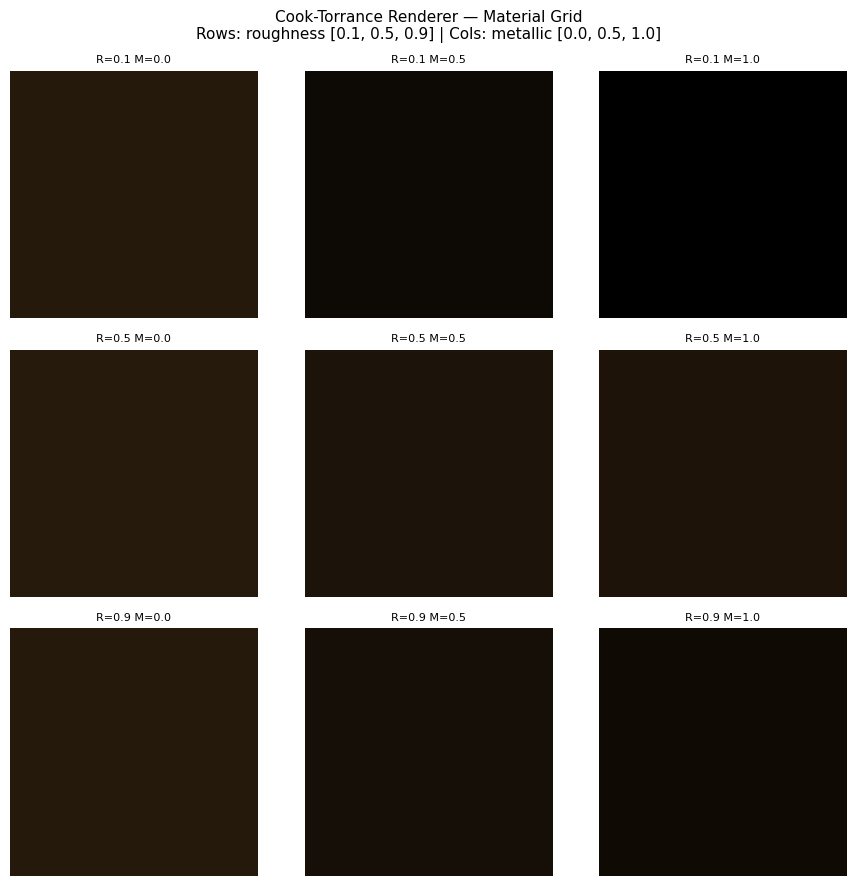

Figure saved: renderer_material_grid.png


In [9]:
def render_material_grid():
    """
    Renders a grid of 9 synthetic flat materials under 3 lights:
        rows    → roughness in {0.1, 0.5, 0.9}
        columns → metallic  in {0.0, 0.5, 1.0}
 
    Expected appearance:
    - Top-left  (smooth, dielectric): sharp bright specular, neutral colour.
    - Bottom-left (rough, dielectric): broad, dim specular; predominantly diffuse.
    - Top-right  (smooth, metal): sharp coloured specular (tinted by albedo).
    - Bottom-right (rough, metal): broad coloured specular, no diffuse.
    """
    H, W = 128, 128
    roughness_values = [0.1, 0.5, 0.9]
    metallic_values  = [0.0, 0.5, 1.0]
    albedo_color     = torch.tensor([0.7, 0.45, 0.2], device=DEVICE)  # warm copper-ish
 
    # Fixed 3-light rig for deterministic visual output
    torch.manual_seed(0)
    dirs, rgb = sample_light_directions(1, 3, DEVICE, DTYPE,
                                        cos_theta_min=0.6, cos_theta_max=0.85)
 
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    fig.suptitle("Cook-Torrance Renderer — Material Grid\n"
                 "Rows: roughness [0.1, 0.5, 0.9] | Cols: metallic [0.0, 0.5, 1.0]",
                 fontsize=11)
 
    for i, rough_val in enumerate(roughness_values):
        for j, metal_val in enumerate(metallic_values):
            albedo = albedo_color.view(1, 3, 1, 1).expand(1, 3, H, W).clone()
            N_pred = torch.zeros(1, 3, H, W, device=DEVICE); N_pred[:, 2] = 1.0
            R_pred = torch.full((1, 1, H, W), rough_val, device=DEVICE)
            M_pred = torch.full((1, 1, H, W), metal_val, device=DEVICE)
 
            with torch.no_grad():
                render = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)
 
            # Simple Reinhard tone mapping for display; renderer output is linear HDR
            render_tm = render / (1.0 + render)
            img = render_tm.squeeze(0).permute(1, 2, 0).cpu().numpy()
            img = np.clip(img, 0, 1)
 
            axes[i][j].imshow(img)
            axes[i][j].set_title(f"R={rough_val:.1f} M={metal_val:.1f}", fontsize=8)
            axes[i][j].axis("off")
 
    plt.tight_layout()
    plt.savefig("renderer_material_grid.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figure saved: renderer_material_grid.png")
 
 
render_material_grid()

## Cell 10 — Performance benchmark

In [10]:
def benchmark_renderer():
    """
    Measures renderer throughput at training-realistic batch sizes.
    Target: < 50 ms per forward pass (B=8, K=3, 256×256) on T4/P100.
    If this target is exceeded significantly, consider reducing K or H/W.
    """
    if not torch.cuda.is_available():
        print("Benchmark skipped (no CUDA).")
        return
 
    configs = [
        (8,  3, 256),
        (8,  3, 320),
        (4,  3, 256),
    ]
 
    for B, K, res in configs:
        albedo = torch.rand(B, 3, res, res, device=DEVICE)
        N_pred = torch.randn(B, 3, res, res, device=DEVICE)
        R_pred = torch.rand(B, 1, res, res, device=DEVICE)
        M_pred = torch.rand(B, 1, res, res, device=DEVICE)
        dirs, rgb = sample_light_directions(B, K, DEVICE, DTYPE)
 
        # Warm-up
        for _ in range(3):
            _ = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)
        torch.cuda.synchronize()
 
        # Timed runs
        n_runs = 20
        t0 = time.perf_counter()
        for _ in range(n_runs):
            _ = cook_torrance_render(albedo, N_pred, R_pred, M_pred, dirs, rgb)
        torch.cuda.synchronize()
        elapsed_ms = (time.perf_counter() - t0) / n_runs * 1000
 
        status = "OK" if elapsed_ms < 50 else "SLOW"
        print(f"  [{status}] B={B} K={K} res={res}x{res}: {elapsed_ms:.1f} ms/forward")
 
    print("\n>>> Record benchmark results")
 
 
benchmark_renderer()

  [OK] B=8 K=3 res=256x256: 7.1 ms/forward
  [OK] B=8 K=3 res=320x320: 11.1 ms/forward
  [OK] B=4 K=3 res=256x256: 3.0 ms/forward

>>> Record benchmark results


## Summary
#
# If all cells above passed, the Cook-Torrance renderer is validated and safe
# to integrate into the MatForge training loss.